In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Starting the plant disease classification process using AlexNet...
Dataset already extracted!
Loading data...
Found 32572 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Found 10885 images belonging to 38 classes.

Total training samples: 32572
Total validation samples: 10849
Total test samples: 10885
Steps per epoch: 1018
Number of classes: 38
Creating AlexNet model...
Starting training...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 200s 180ms/step - accuracy: 0.2482 - loss: 3.3909 - val_accuracy: 0.2861 - val_loss: 4.5844 - learning_rate: 0.0010
Epoch 2/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 170s 167ms/step - accuracy: 0.5141 - loss: 1.8455 - val_accuracy: 0.6095 - val_loss: 1.5022 - learning_rate: 0.0010
Epoch 3/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 171s 168ms/step - accuracy: 0.5882 - loss: 1.4880 - val_accuracy: 0.6802 - val_loss: 1.2353 - learning_rate: 0.0010
Epoch 4/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 200s 166ms/step - accuracy: 0.6428 - loss: 1.2656 - val_accuracy: 0.6095 - val_loss: 1.4615 - learning_rate: 0.0010
Epoch 5/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 169s 166ms/step - accuracy: 0.6413 - loss: 1.2758 - val_accuracy: 0.6025 - val_loss: 1.9851 - learning_rate: 0.0010
Epoch 6/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 170s 167ms/step - accuracy: 0.7001 - loss: 1.0210 - val_accuracy: 0.7221 - val_loss: 1.0654 - learning_rate: 5.0000e-04
Epoch 7/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 174s 1

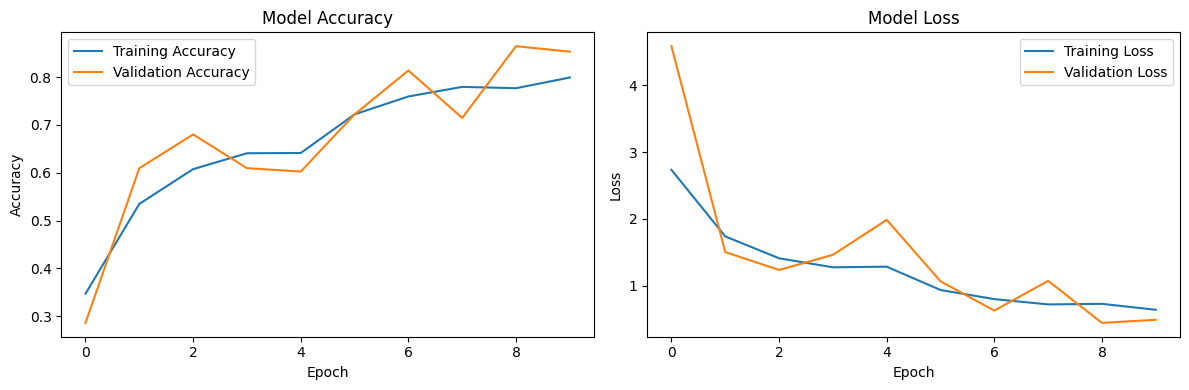

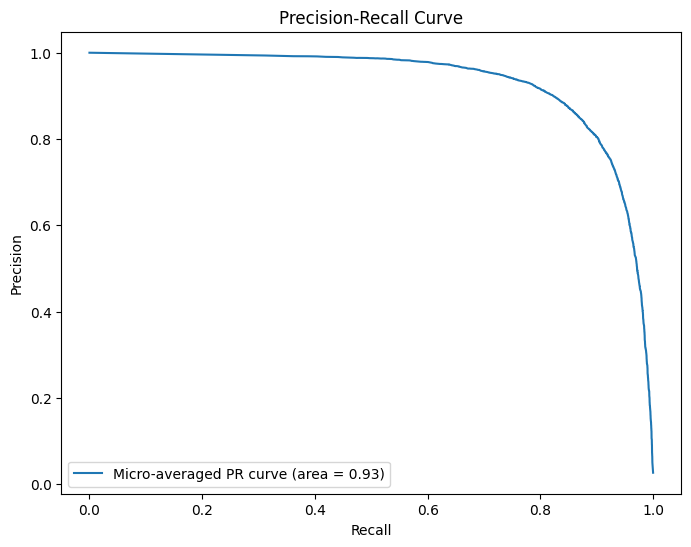


Final Accuracies:
Training Accuracy: 0.7992
Validation Accuracy: 0.8531
Testing Accuracy: 0.8582


In [16]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, Activation
)
import matplotlib.pyplot as plt
from google.colab import drive
import zipfile
from sklearn.metrics import precision_recall_curve, auc

# Enable mixed precision training
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Mount Google Drive
drive.mount('/content/drive')

def create_alexnet(input_shape=(128, 128, 3), num_classes=38):
    model = Sequential([
        # First Convolutional Layer
        Conv2D(96, kernel_size=11, strides=4, padding='valid', input_shape=input_shape),
        Activation('relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=3, strides=2),

        # Second Convolutional Layer
        Conv2D(256, kernel_size=5, padding='same'),
        Activation('relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=3, strides=2),

        # Third Convolutional Layer
        Conv2D(384, kernel_size=3, padding='same'),
        Activation('relu'),
        BatchNormalization(),

        # Fourth Convolutional Layer
        Conv2D(384, kernel_size=3, padding='same'),
        Activation('relu'),
        BatchNormalization(),

        # Fifth Convolutional Layer
        Conv2D(256, kernel_size=3, padding='same'),
        Activation('relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=3, strides=2),

        # Flatten layer
        Flatten(),

        # Dense Layers
        Dense(4096),
        Activation('relu'),
        Dropout(0.5),
        BatchNormalization(),

        Dense(4096),
        Activation('relu'),
        Dropout(0.5),
        BatchNormalization(),

        # Output Layer
        Dense(num_classes, activation='softmax')
    ])

    return model

def extract_dataset():
    zip_path = "/content/drive/MyDrive/Copy of PLANT_VILLAGE_SPLIT.zip"
    extract_path = "/content/plant_village"

    if not os.path.exists(extract_path):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Extraction complete!")
    else:
        print("Dataset already extracted!")
    return extract_path

def load_data(base_path, img_size=(128, 128)):
    data_generator = ImageDataGenerator(
        rescale=1./255,
        horizontal_flip=True,
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        fill_mode="nearest"
    )

    # Setup data generators
    train_generator = data_generator.flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'train'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=True
    )

    # No augmentation for validation and test
    val_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'val'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'test'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    print(f"\nTotal training samples: {train_generator.n}")
    print(f"Total validation samples: {val_generator.n}")
    print(f"Total test samples: {test_generator.n}")
    print(f"Steps per epoch: {len(train_generator)}")

    return train_generator, val_generator, test_generator

def train_and_evaluate():
    # Extract dataset
    base_path = extract_dataset()

    # Load data
    print("Loading data...")
    train_generator, val_generator, test_generator = load_data(base_path)
    num_classes = len(train_generator.class_indices)
    print(f"Number of classes: {num_classes}")

    # Create and compile model
    print("Creating AlexNet model...")
    model = create_alexnet(input_shape=(128, 128, 3), num_classes=num_classes)

    # Fixed learning rate configuration
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Add callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2
        )
    ]

    # Train model
    print("Starting training...")
    history = model.fit(
        train_generator,
        epochs=10,
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate on test set
    print("Evaluating on test set...")
    test_loss, test_accuracy = model.evaluate(test_generator)
    print(f"Test accuracy: {test_accuracy:.4f}")

    # Get predictions for PR curve
    y_pred = model.predict(test_generator)
    y_test = test_generator.labels
    y_test = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

    # Plot training history
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Plot PR curve
    plt.figure(figsize=(8, 6))
    precision = dict()
    recall = dict()

    for i in range(num_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_pred[:, i])

    precision["micro"], recall["micro"], _ = precision_recall_curve(y_test.ravel(), y_pred.ravel())

    plt.plot(recall["micro"], precision["micro"], label=f'Micro-averaged PR curve (area = {auc(recall["micro"], precision["micro"]):.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

    return (history.history['accuracy'][-1],
            history.history['val_accuracy'][-1],
            test_accuracy)

if __name__ == "__main__":
    print("Starting the plant disease classification process using AlexNet...")
    train_acc, val_acc, test_acc = train_and_evaluate()
    print(f"\nFinal Accuracies:")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")